# Verifying Measurement-Based Uncomputation

In [1]:
import itertools
from qualtran.bloqs.mcmt import And

and_dag = And(uncompute=True)
for q1, q2 in itertools.product(range(2), repeat=2):
    trg = int(q1==1 and q2 == 1)
    print(f'{q1=}, {q2=}, {trg=}', end='  ')
    (q1o, q2o), = and_dag.call_classically(ctrl=[q1,q2], target=trg)
    assert q1o == q1
    assert q2o == q2
    print('✓')

q1=0, q2=0, trg=0  ✓
q1=0, q2=1, trg=0  ✓
q1=1, q2=0, trg=0  ✓
q1=1, q2=1, trg=1  ✓


In [2]:
try:
    and_dag.call_classically(ctrl=[1,1], target=0)
except ValueError as e:
    print(e)

Inconsistent `target` found for uncomputing `And`: ctrl=array([1, 1], dtype=uint8), target=0. Expected target=1


## MBUC circuit for $\mathrm{And}^\dagger$

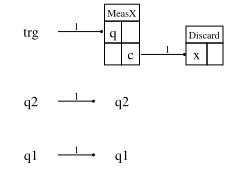

In [7]:
from qualtran import Side, BloqBuilder, Register, QBit, CtrlSpec, Controlled, CBit

from qualtran.bloqs.basic_gates.x_basis import MeasX, PlusState
from qualtran.bloqs.basic_gates.z_basis import MeasZ, ZeroState
from qualtran.bloqs.basic_gates import CZ, Hadamard, CNOT
from qualtran.bloqs.basic_gates.discard import Discard


bb = BloqBuilder()
q1 = bb.add_register('q1', 1)
q2 = bb.add_register('q2', 1)
trg = bb.add_register(Register('trg', QBit(), side=Side.LEFT))

ctrg = bb.add(MeasX(), q=trg)
bb.add(Discard(), x=ctrg)

cbloq = bb.finalize(q1=q1, q2=q2)
from qualtran.drawing import show_bloq
show_bloq(cbloq)

In [60]:
from qualtran.simulation.classical_sim import do_phased_classical_simulation

in_vals = {'q1': 1, 'q2': 1, 'trg': 1}
out_vals, phase = do_phased_classical_simulation(cbloq, in_vals)
print(out_vals)
print(phase)

{'q1': 1, 'q2': 1}
-1.0


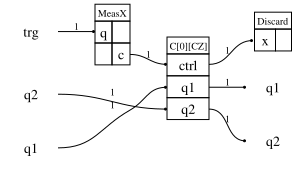

In [61]:
from qualtran import Side, BloqBuilder, Register, QBit, CtrlSpec, Controlled, CBit

from qualtran.bloqs.basic_gates.x_basis import MeasX, PlusState
from qualtran.bloqs.basic_gates.z_basis import MeasZ, ZeroState
from qualtran.bloqs.basic_gates import CZ, Hadamard, CNOT
from qualtran.bloqs.basic_gates.discard import Discard


bb = BloqBuilder()
q1 = bb.add_register('q1', 1)
q2 = bb.add_register('q2', 1)
trg = bb.add_register(Register('trg', QBit(), side=Side.LEFT))

ctrg = bb.add(MeasX(), q=trg)
classicall_controlled_cz = Controlled(CZ(), CtrlSpec(qdtypes=(CBit(),), cvs=1))

ctrg, q1, q2 = bb.add(
    classicall_controlled_cz,
    **{'ctrl': ctrg,
       'q1': q1,
       'q2': q2
      }
)
bb.add(Discard(), x=ctrg)

cbloq = bb.finalize(q1=q1, q2=q2)
from qualtran.drawing import show_bloq
show_bloq(cbloq)

In [79]:
from qualtran.simulation.classical_sim import do_phased_classical_simulation

in_vals = {'q1': 1, 'q2': 1, 'trg': 1}
out_vals, phase = do_phased_classical_simulation(cbloq, in_vals)
print(out_vals)
print(phase)

{'q1': 1, 'q2': 1}
1.0


### Interface

In [80]:
from qualtran.simulation.classical_sim import do_phased_classical_simulation

in_vals = {'q1': 1, 'q2': 1, 'trg': 1}
out_vals, phase = do_phased_classical_simulation(cbloq, in_vals)
phase

1.0

### Exhaustive sweep over `MeasX` results

In [81]:
def run_debug_sim_2(sim):
    try:
        while True:
            sim.step()
            if sim.phase == 1.0:
                print('+', end='')
            elif sim.phase == -1.0:
                print('-', end='')
            else:
                print('?', end='')
            
    except StopIteration:
        res = sim.finalize()
    return res, sim.phase

In [82]:
from qualtran.simulation.classical_sim import _PhasedClassicalSimState
import itertools

meas_binst_is = [binst.i for binst in cbloq.bloq_instances if binst.bloq_is(MeasX)]


for q1, q2 in itertools.product(range(2), repeat=2):
    trg = int(q1==1 and q2 == 1)
    print(f'{q1=}, {q2=}, {trg=}')

    for meas_result in itertools.product(range(2), repeat=len(meas_binst_is)):
        print(f'  meas {meas_result}', end=' ')
        meas_results = {binst_i: meas_result[j] for j, binst_i in enumerate(meas_binst_is)}

        sim = _PhasedClassicalSimState.from_cbloq(cbloq, {'q1': q1, 'q2': q2, 'trg':trg}, fixed_rnd_vals=meas_results)
        #out_vals = sim.simulate()
        out_vals, phase = run_debug_sim_2(sim)
        
        assert out_vals['q1'] == q1
        assert out_vals['q2'] == q2
        assert 'trg' not in out_vals
        assert phase == 1.0
        print(' ✓')
        


q1=0, q2=0, trg=0
  meas (0,) +++++ ✓
  meas (1,) +++++ ✓
q1=0, q2=1, trg=0
  meas (0,) +++++ ✓
  meas (1,) +++++ ✓
q1=1, q2=0, trg=0
  meas (0,) +++++ ✓
  meas (1,) +++++ ✓
q1=1, q2=1, trg=1
  meas (0,) +++++ ✓
  meas (1,) +-+++ ✓
